# Visualize one episode — joint plot + composed video

Renders one episode of the released LeRobotDataset into:
1. a **composed mp4** — top row: head / left-wrist / right-wrist RGB; middle row: 5 left
   fingertips (raw, deform, F6 bars); bottom row: 5 right fingertips;
2. a **joint state-vs-target plot** (state solid, action/target dashed).

Uses `cv2` (`uv pip install -e '.[viz]'`) + the package `decode`/`hub`/`schema` helpers.
Reference: `SharpaDexmateTeleop/teleop/scripts/analysis.ipynb`.

_Note:_ this decodes all 23 video streams for the episode into memory (a few GB for a
~1000-frame episode) — fine on a workstation; chunk the frame loop for very long episodes.

In [1]:
import time
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt

from trex_dataset_quickstart import decode, hub, schema

## Config

In [2]:
SOURCE = "zekaiwang/trex_dataset"  # HF repo id, or a path to a local dataset dir
EPISODE_INDEX = 1234
OUT_DIR = Path("episode_viz")  # where the mp4 + png are written
FPS = schema.FPS

# display sizes (px)
TILE = 150  # per-finger tactile tile (raw / deform), square
F6_PANEL_H = 110  # height of the F6 bar chart under each finger
CAM_H = 300  # height of each top-row RGB camera
F6_RANGE = 5.0  # F6 bars clamped to +/- this

OUT_DIR.mkdir(parents=True, exist_ok=True)

## Load the episode (videos + state / action / tactile_force)

In [3]:
root = hub.fetch_episode(SOURCE, EPISODE_INDEX, include_videos=True)
episodes = hub.load_episodes(root)
rows = episodes[episodes["episode_index"] == EPISODE_INDEX]
if len(rows) == 0:
    raise ValueError(f"episode_index {EPISODE_INDEX} not found in {SOURCE}")
ep_row = rows.iloc[0]
length = int(ep_row["length"])

state = decode.load_episode_state(root, EPISODE_INDEX, length)  # (T, 58)
action = decode.load_episode_action(root, EPISODE_INDEX, length)  # (T, 58) targets
f6 = decode.load_episode_f6(root, EPISODE_INDEX, length)  # (T, 60)
print(f"episode {EPISODE_INDEX}: {length} frames")

Fetching 4 files:   0%|          | 0/4 [00:00<?, ?it/s]

meta/tasks.parquet:   0%|          | 0.00/206k [00:00<?, ?B/s]

meta/episodes/chunk-000/file-000.parquet:   0%|          | 0.00/64.6M [00:00<?, ?B/s]

stats.json: 0.00B [00:00, ?B/s]

info.json: 0.00B [00:00, ?B/s]

...

videos/observation.images.tactile_right_(…):   0%|          | 0.00/202M [00:00<?, ?B/s]

videos/observation.images.tactile_right_(…):   0%|          | 0.00/200M [00:00<?, ?B/s]

videos/observation.images.tactile_right_(…):   0%|          | 0.00/208M [00:00<?, ?B/s]

videos/observation.images.tactile_right_(…):   0%|          | 0.00/201M [00:00<?, ?B/s]

episode 1234: 751 frames


## Decode all video streams

3 RGB cameras + 20 tactile (5 fingers x raw/deform x 2 hands).

In [4]:
# RGB cameras (rgb24) and tactile (grayscale uint8), keyed by feature name.
frames = {}
for key in schema.RGB_KEYS:
    frames[key] = decode.decode_key(root, key, ep_row, length, gray=False)  # (T, H, W, 3)
for side in ("left", "right"):
    for kind in ("raw", "deform"):
        for fng in schema.FINGER_NAMES:
            key = schema.tactile_video_key(side, kind, fng)
            frames[key] = decode.decode_key(root, key, ep_row, length, gray=True)  # (T, H, W)
print("decoded keys:", len(frames))

decoded keys: 23


## Rendering helpers (cv2; mirrors analysis.ipynb)

In [5]:
F6_LABELS = ["Fx", "Fy", "Fz", "Mx", "My", "Mz"]


def render_f6_bars(f6_vec, width, height):
    """6-component F6 vector -> vertical bar chart (BGR); bars grow up(+)/down(-) from center."""
    img = np.zeros((height, width, 3), dtype=np.uint8)
    mid_y = height // 2
    cv2.line(img, (0, mid_y), (width, mid_y), (80, 80, 80), 1)
    n = len(f6_vec)
    slot_w = width / n
    bar_w = max(2, int(slot_w * 0.6))
    max_bar = mid_y - 14
    for i in range(n):
        frac = float(np.clip(f6_vec[i] / F6_RANGE, -1.0, 1.0))
        bar_px = int(abs(frac) * max_bar)
        cx = int((i + 0.5) * slot_w)
        x0, x1 = cx - bar_w // 2, cx + bar_w // 2
        if frac >= 0:
            y0, y1, color = mid_y - bar_px, mid_y, (0, 200, 0)  # green up
        else:
            y0, y1, color = mid_y, mid_y + bar_px, (0, 140, 255)  # orange down
        cv2.rectangle(img, (x0, y0), (x1, y1), color, -1)
        cv2.putText(
            img,
            F6_LABELS[i],
            (cx - 9, height - 3),
            cv2.FONT_HERSHEY_SIMPLEX,
            0.3,
            (180, 180, 180),
            1,
        )
    return img


def _label(img, text, color=(255, 255, 255)):
    cv2.putText(img, text, (4, 16), cv2.FONT_HERSHEY_SIMPLEX, 0.5, color, 1)
    return img


def finger_panel(raw_u8, deform_u8, f6_vec, name):
    """One finger column (BGR), top->bottom: raw grayscale, deform grayscale, F6 bars."""
    raw_bgr = cv2.cvtColor(cv2.resize(raw_u8, (TILE, TILE)), cv2.COLOR_GRAY2BGR)
    _label(raw_bgr, name, (0, 255, 0))
    deform_bgr = cv2.cvtColor(cv2.resize(deform_u8, (TILE, TILE)), cv2.COLOR_GRAY2BGR)
    _label(deform_bgr, f"|F6| {float(np.linalg.norm(f6_vec)):.1f}", (255, 255, 0))
    bars = render_f6_bars(f6_vec, TILE, F6_PANEL_H)
    return np.vstack([raw_bgr, deform_bgr, bars])


def hand_row(side, t):
    panels = [
        finger_panel(
            frames[schema.tactile_video_key(side, "raw", fng)][t],
            frames[schema.tactile_video_key(side, "deform", fng)][t],
            decode.f6_slice(f6[t], side, fi),
            f"{side[0].upper()}-{fng}",
        )
        for fi, fng in enumerate(schema.FINGER_NAMES)
    ]
    return np.hstack(panels)


def cam_row(t):
    cams = []
    for key in schema.RGB_KEYS:
        bgr = cv2.cvtColor(frames[key][t], cv2.COLOR_RGB2BGR)
        scale = CAM_H / bgr.shape[0]
        bgr = cv2.resize(bgr, (int(bgr.shape[1] * scale), CAM_H))
        _label(bgr, key.split(".")[-1])
        cams.append(bgr)
    return np.hstack(cams)


def _pad_to_width(img, w):
    if img.shape[1] >= w:
        return img
    return np.hstack([img, np.zeros((img.shape[0], w - img.shape[1], 3), dtype=np.uint8)])


def compose(t):
    rows = [cam_row(t), hand_row("left", t), hand_row("right", t)]
    w = max(r.shape[1] for r in rows)
    return np.vstack([_pad_to_width(r, w) for r in rows])

## Render the video

In [6]:
out_mp4 = OUT_DIR / f"episode_{EPISODE_INDEX:06d}_viz.mp4"
writer = None
t0 = time.time()
for t in range(length):
    frame = compose(t)
    if writer is None:
        h, w = frame.shape[:2]
        writer = cv2.VideoWriter(str(out_mp4), cv2.VideoWriter_fourcc(*"mp4v"), float(FPS), (w, h))
        assert writer.isOpened(), f"could not open VideoWriter for {out_mp4}"
        print(f"frame size: {w}x{h}")
    writer.write(frame)
writer.release()
print(f"wrote {out_mp4}  ({length} frames, {time.time() - t0:.1f}s)")

frame size: 1599x1120


wrote episode_viz/episode_001234_viz.mp4  (751 frames, 4.5s)


## Preview a composed frame inline

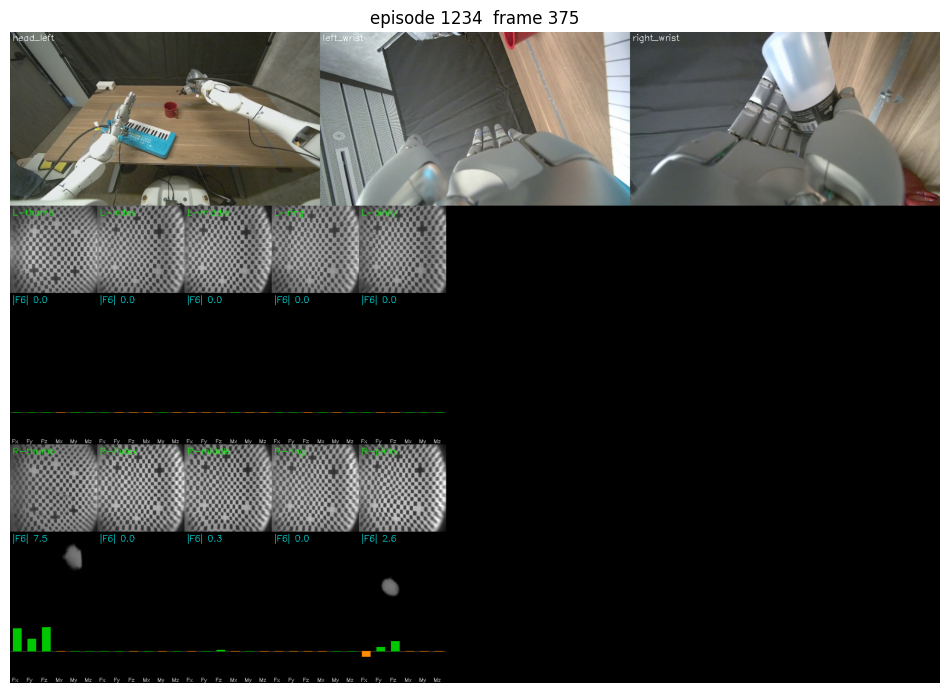

In [7]:
t_preview = length // 2
plt.figure(figsize=(12, 9))
plt.imshow(cv2.cvtColor(compose(t_preview), cv2.COLOR_BGR2RGB))
plt.axis("off")
plt.title(f"episode {EPISODE_INDEX}  frame {t_preview}")
plt.show()
# To embed the whole video inline:
# from IPython.display import Video; Video(str(out_mp4), embed=True, width=640)

## Joint state vs target plot

wrote episode_viz/episode_001234_joints.png


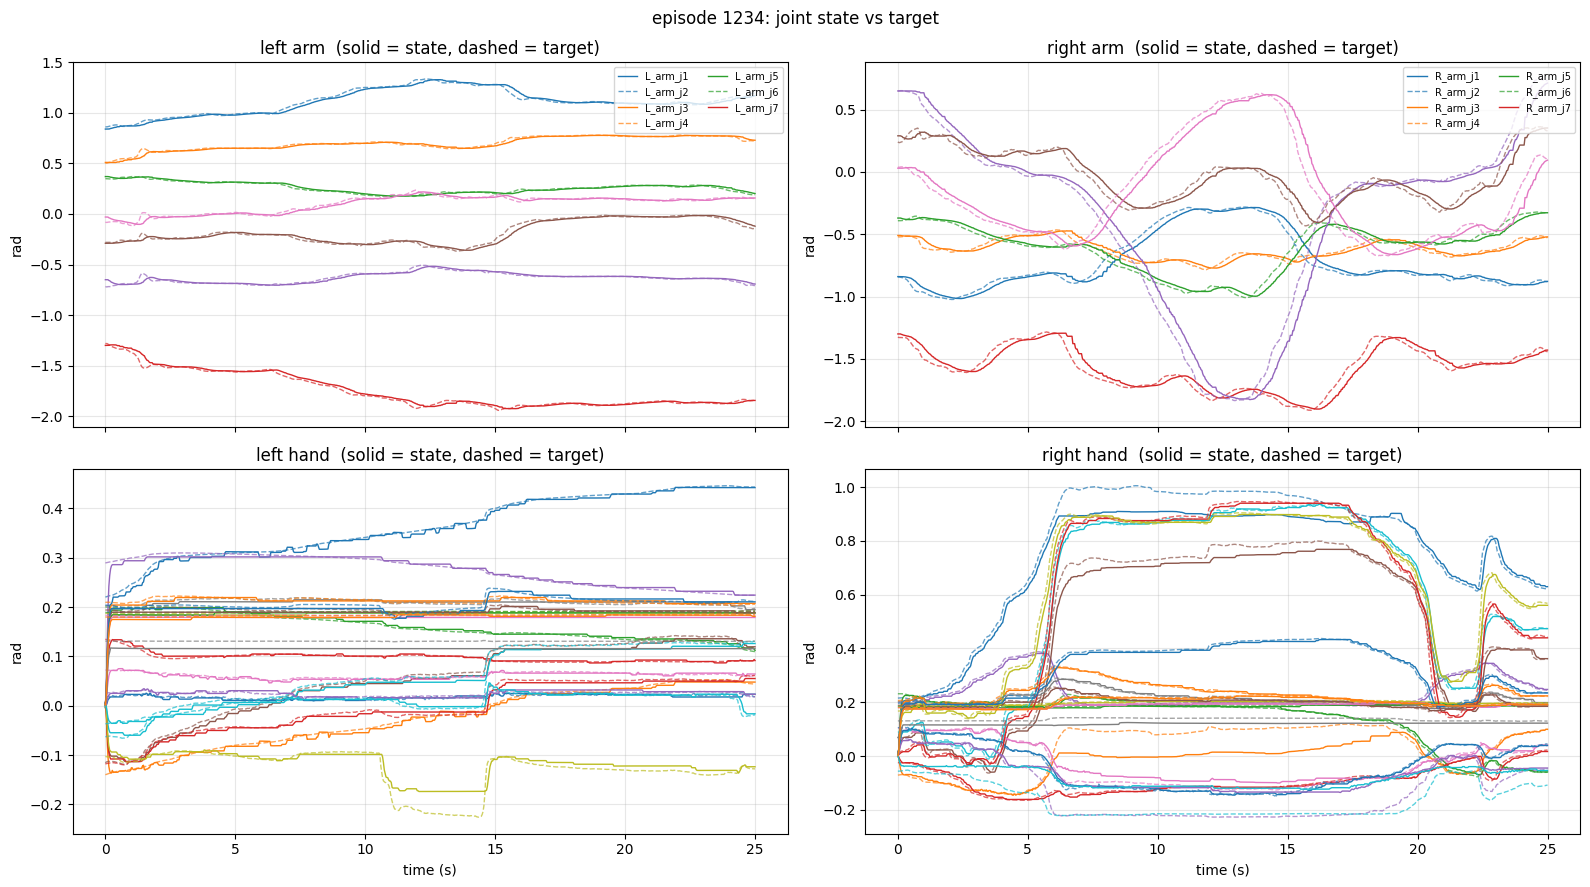

In [8]:
t_axis = np.arange(length) / FPS
groups = [
    ("left arm", schema.LEFT_ARM, list(schema.LEFT_ARM_JOINTS)),
    ("right arm", schema.RIGHT_ARM, list(schema.RIGHT_ARM_JOINTS)),
    ("left hand", schema.LEFT_HAND, [f"left_{n}" for n in schema.SHARPA_HAND_JOINT_ORDER]),
    ("right hand", schema.RIGHT_HAND, [f"right_{n}" for n in schema.SHARPA_HAND_JOINT_ORDER]),
]
fig, axes = plt.subplots(2, 2, figsize=(16, 9), sharex=True)
for ax, (title, sl, names) in zip(axes.ravel(), groups):
    for j, name in zip(range(sl.start, sl.stop), names):
        (line,) = ax.plot(t_axis, state[:, j], lw=1.0)
        ax.plot(t_axis, action[:, j], lw=1.0, ls="--", color=line.get_color(), alpha=0.7)
    ax.set_title(f"{title}  (solid = state, dashed = target)")
    ax.set_ylabel("rad")
    ax.grid(alpha=0.3)
    if "arm" in title:
        ax.legend(names, fontsize=7, ncol=2, loc="upper right")
for ax in axes[-1]:
    ax.set_xlabel("time (s)")
fig.suptitle(f"episode {EPISODE_INDEX}: joint state vs target")
fig.tight_layout()
out_png = OUT_DIR / f"episode_{EPISODE_INDEX:06d}_joints.png"
fig.savefig(out_png, dpi=120)
print("wrote", out_png)
plt.show()